# **Causal Effect ANalysis**

### **Problems:**
1) Memory Test on Drugged Islanders: Does the drug Xanax cause high memory recal after drug is administered?

2) School Lunch Program: Does free lunch at schools cause an improvement in grades?

3) Caffeine Intake: Does the amount of coffee consumed cause more energy?

In [692]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
import statsmodels.api as sm


---

# **(1) Memory Test on Drugged Islanders: Does the drug Xanax cause higher memory recal after drug is administered?**

### **Dataset Used:**

https://www.kaggle.com/datasets/steveahn/memory-test-on-drugged-islanders-data

### **Dataset Description:**

**Context:**

An experiment on the effects of anti-anxiety medicine on memory recall when being primed with happy or sad memories. The participants were done on novel Islanders whom mimic real-life humans in response to external factors.

Drugs of interest (known-as) [Dosage 1, 2, 3]:

A - Alprazolam (Xanax, Long-term) [1mg/3mg/5mg]

T - Triazolam (Halcion, Short-term) [0.25mg/0.5mg/0.75mg]

S- Sugar Tablet (Placebo) [1 tab/2tabs/3tabs]

*Dosages follow a 1:1 ratio to ensure validity *Happy or Sad memories were primed 10 minutes prior to testing *Participants tested every day for 1 week to mimic addiction

**Building the Case: Obstructive effects of Benzodiazepines (Anti-Anxiety Medicine):** Long term adverse effects on Long Term Potentiation of synapses, metacognition and memory recall ability http://www.jstor.org/stable/43854146

**Happy Memories:** Research shown positive memories to have a deeper and greater volume of striatum representation under an fMRI https://www.sciencedirect.com/science/article/pii/S0896627314008484

**Sad Memories:** Research shown sad memories invokes better memory recall for evolutionary purpose whereas, happy memories are more susceptible to false memories http://www.jstor.org/stable/40064315

**Participants:** All genders above 25+ years old to ensure a fully developed pre-frontal cortex, a region responsible for higher level cognition and memory recall.

**Content:** File contains information on participants drug treatment information along with their test scores.

**Acknowledgements:** Experiment was executed under the supervision of Mr. Almohalwas at UCLA. All aspects of the experiment such as experimental design, data collection and preprocessing was done from the authour Steve Ahn.

### **Innitial Assumption:**
- Does the drug Xanax cause higher memory recal after drug is administered?

### **Linear Regression Analysis for Causal Effect:**

> $y_i$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_i$

$y_i$ = The outcome variable. The dependent variable.

$\beta_0$ = The average change in outcome of the control group.

$\beta_1$ = The Average Treatment Effect (ATE), or the estimated causal effect. The estimated difference of the change in the outcome between the treatment and control groups.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- Memory score after.
- This is the memory recal time in seconds which measures how long it took to finish a memory test after addiction achieved.
- The drug that was tested is Alprazolam (Xanax, Long-term), an anti-anxiety medication.

### **Treatment Variable:**
- Drug, where the treated group were the islanders who took A - Alprazolam (Xanax, Long-term) [1mg/3mg/5mg], and the control were the islanders who took S- Sugar Tablet (Placebo) [1 tab/2tabs/3tabs].
- Treated = 1 = A - Alprazolam (Xanax, Long-term) [1mg/3mg/5mg].
- Control = 0 = S- Sugar Tablet (Placebo) [1 tab/2tabs/3tabs].

**Note:**
- It is important to note that, after further reading the "islanders" are computer generated beings to mimick humans.
- Therefore, the sample was not generated at random, and the islanders where not assigned treatment randomly.
- Therefore, we must control for cofounders, and we can allso not definitively conclude that there is a causal effect between taking Xanax and high memory recal, even if the relationship is significant.

### **Possible Cofounders:**
- Since both the treatment assignment and the sample are not random due to their nature as computer generated human like beings, we must control for possible cofounders.
    - Age, age of islanders.
    - Happy/Sad Group, happy or sad memory priming block. 0 = S = Sad, 1 = H = Happy.
    - Dosage, 1-3 to indicate the level of dosage (low - medium - over recommended daily intake).
    - Memory Score Before, seconds - how long it took to finish a memory test before drug exposure.

### **Linear Regression Equation for Problem:**
> Memory Score After in Seconds = $\beta_0$ + $\beta_1$ (Drug, 1 = Treated Xanax, 0 = control Sugar Tablet) + $\beta_2$ (Age) + $\beta_3$ (Happy/Sad Group, 1 = Happy, 0 = Sad) + $\beta_4$ (Medium Dosage) + $\beta_5$ (Over Recommended Daily Intake Dosage) + $\beta_6$ (Memory Score Before in Seconds) + $\epsilon_i$

---

## **Importing, Cleaning, and Getting Data Ready:**

In [693]:
df = pd.read_csv("C:\BROCK U COURSE DOCS\DataSets\Islander_data.csv")
df

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3
1,Evan,Carrasco,52,S,1,A,41.6,40.7,-0.9
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6
3,Holly,Carrasco,50,S,1,A,51.7,51.2,-0.5
4,Justin,Carrasco,52,H,1,A,47.0,47.1,0.1
...,...,...,...,...,...,...,...,...,...
193,Jacob,Novak,52,H,3,T,71.3,74.3,3.0
194,Teo,Steiner,41,S,3,T,72.5,70.4,-2.1
195,Alexander,Takahashi,54,S,3,T,30.8,33.1,2.3
196,Alexandere,Takahashi,40,H,3,T,53.6,53.8,0.2


In [694]:
df = df[df['Drug'] != 'T'].copy()

> Removed the drug T - Triazolam (Halcion, Short-term) [0.25mg/0.5mg/0.75mg].

In [695]:
df['Drug'] = df['Drug'].map({'A': 1, 'S': 0})

> Converted Drug column to binary. 1 = A - Alprazolam (Xanax, Long-term) [1mg/3mg/5mg], 0 = S- Sugar Tablet (Placebo) [1 tab/2tabs/3tabs].

In [696]:
df['Happy_Sad_group'] = df['Happy_Sad_group'].map({'H': 1, 'S': 0})

> Converted the happy sad group column to binary. 1 = happy, 0 = sad.

In [697]:
dummies = pd.get_dummies(data= df['Dosage'], drop_first= True).astype(int)

df['Medium_Dosage'] = dummies[2]
df['Over_Dosage'] = dummies[3]
df

,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff,Medium_Dosage,Over_Dosage
0,Bastian,Carrasco,25,1,1,1,63.5,61.2,-2.3,0,0
1,Evan,Carrasco,52,0,1,1,41.6,40.7,-0.9,0,0
2,Florencia,Carrasco,29,1,1,1,59.7,55.1,-4.6,0,0
3,Holly,Carrasco,50,0,1,1,51.7,51.2,-0.5,0,0
4,Justin,Carrasco,52,1,1,1,47.0,47.1,0.1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
128,Chloe,Steiner,28,0,3,0,69.7,71.9,2.2,0,1
129,Nik,Summers,38,1,3,0,88.7,96.0,7.3,0,1
130,Tobias,Summers,43,0,3,0,49.3,52.7,3.4,0,1
131,Anna,Takahashi,45,1,3,0,81.9,80.6,-1.3,0,1


> Converting dosage types to dummy variables, where 0 in both columns is low, 1 in the first column is medium, and 1 in the second column is over recommended daily intake.

In [698]:
df.duplicated().sum()

np.int64(0)

> No duplicated rows need to be removed.

In [699]:
df.isna().sum()

first_name          0
last_name           0
age                 0
Happy_Sad_group     0
Dosage              0
Drug                0
Mem_Score_Before    0
Mem_Score_After     0
Diff                0
Medium_Dosage       0
Over_Dosage         0
dtype: int64

> No NaN values to be removed.

---

## **Building the Model and Printing Results:**

In [700]:
df.columns

Index(['first_name', 'last_name', 'age', 'Happy_Sad_group', 'Dosage', 'Drug',
       'Mem_Score_Before', 'Mem_Score_After', 'Diff', 'Medium_Dosage',
       'Over_Dosage'],
      dtype='object')

In [701]:
y = df['Mem_Score_After']

x = df[['Drug', 'age', 'Happy_Sad_group', 'Medium_Dosage', 'Over_Dosage', 'Mem_Score_Before']]
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Mem_Score_After   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     54.42
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           1.14e-32
Time:                        16:38:16   Log-Likelihood:                -493.80
No. Observations:                 133   AIC:                             1002.
Df Residuals:                     126   BIC:                             1022.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.7227      5.113     -0.141      0.888     -10.841       9.396
Drug                 9.6861      1.780      5.441      0.000       6.163      13.209
age                 -0.0040      0.083     -0.048      0.962      -0.169       0.161
Happy_Sad_group     -1.0163      1.775     -0.573      0.568      -4.529       2.496
Medium_Dosage        1.4707      2.168      0.678      0.499      -2.820       5.761
Over_Dosage          9.0385      2.160      4.184      0.000       4.764      13.313
Mem_Score_Before     0.9608      0.057     16.714      0.000       0.847       1.075
==============================================================================
Omnibus:                        8.281   Durbin-Watson:                   1.434
Prob(Omnibus):                  0.016   Jarque-Bera (JB):               16.088
Skew:                          -0.111   Prob(JB):                     0.000321
Kurtosis:                       4.689   Cond. No.                         420.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> Memory Score After in Seconds = -5.9187 + 9.6860 (Drug, 1 = Treated Xanax, 0 = control Sugar Tablet) + 0.0007 (Age) + -1.0330 (Happy/Sad Group, 1 = Happy, 0 = Sad) + 1.4707 (Medium Dosage) + 9.0385 (Over Recommended Daily Intake Dosage) + 0.9608 (Memory Score Before in Seconds) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: The population Drug $\beta_1$ = 0

Ha: The population Drug $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE($\beta_1$)

t-stat = (9.6861 - 0) / 1.780

t-stat = 5.441

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.0001

$\alpha$ = 0.05

=> p-value < $\alpha$

=> 0.0001 < 0.05

=> We reject the null hypothesis; the population Drug $\beta_1$ != 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_1$ - (t[0.05] * SE), $\beta_1$ + (t[0.05] * SE)]

Confidence Interval = [9.6861 - (1.96 * 1.780), 9.6861 + (1.96 * 1.780)]

Confidence Interval = [6.163, 13.209]

=> Confidence interval does not contain zero.

=> Therefore results confirm hypothesis test and population Drug $\beta_1$ is not zero.

### **Description, Reasoning, and Summary:**
- The model does confirm and prove the original statement: does the drug Xanax cause higher memory recal after drug is administered?
- The causal inference model shows that the average treatment effect ATE, or the average difference in the outcome between the treated and controled groups is 9.6861, while all other variables are controlled for.
- This relationship tells us that taking the anti-anxiety drug Xanax will increase memory recal by 9.6861 after the drug is administered and a high is acheived.
- The relationship can also be interpreted as causal. That is, if all significant cofounders are controlled for since the sample and the treatment assignment are not random.
- The reason is that the probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true, is very low.
- Therefore, the null hypothesis is rejected since the p value falls bellow the 0.05 threshold, and the average treatment effect is significant; the population ATE is not equal to zero.
- The difference between the sample ATE and zero, given the standard error, is very high.
- This means that, under the assumption the null hypothesis is true, it does not confirm the null hypothesis to be true, and the null hypothesis does not represent the presented sample data.
- Therefore the probability under the assumption the null hypothesis is true is low and we reject the null hypothesis.
- The ATE is statistically significant and so we can interpret the relationship as causal.
- However, we do not know if there are any other cofounders we have not controlled for. So, we cannot conclude with certainty that the relationship between the taking Xanax and gaining high memory score as causal.

---

# **(2) School Lunch Program: Does free lunch at schools cause an improvement in grades?**

### **Dataset Used:**

https://www.kaggle.com/datasets/bhavikjikadara/student-study-performance

### **Dataset Description:**

**Problem Statement:** This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

**Content:** This data set consists of the marks secured by the students in various subjects.
- gender : sex of students -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B, C, D, and E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,- high school)
- lunch : having lunch before test (standard or free/reduced)
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

**Inspiration:** To understand the influence of the parent's background, test preparation etc on students' performance

### **Innitial Assumption:**
- Does free lunch at schools cause an improvement in grades?

### **Linear Regression Analysis for Causal Effect:**

> $y_i$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_i$

$y_i$ = The outcome variable. The dependent variable.

$\beta_0$ = The average change in outcome of the control group.

$\beta_1$ = The Average Treatment Effect (ATE), or the estimated causal effect. The estimated difference of the change in the outcome between the treatment and control groups.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- Average student grades across math, reading, and writting scores.

### **Treatment Variable:**
- lunch, where 1 = free lunch, and 0 = standard lunch.
- The treatment is not assigned, therefore possible cofounders may exist that we need to control for.

### **Possible Cofounders:**
- gender : sex of students -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B, C, D, and E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,- high school)
- test preparation course : complete or not complete before test

**Note:** There may exist multiple other cofounders that we cannot control for since we have no other data. Therefore, we cannot conclude the relationship is causal, we can only infer causality based on the available data.

### **Linear Regression Equation for Problem:**
> Average Student Grades = $\beta_0$ + $\beta_1$ (lunch, 1 = free, 0 = standard) + $\beta_2$ (Gender, 1 = Female, 0 = Male) + $\beta_3$ (Group B Race/Ethnicity) + $\beta_4$ (Group C Race/Ethnicity) + $\beta_5$ (Group D Race/Ethnicity) + $\beta_6$ (Group E Race/Ethnicity) + $\beta_7$ ( Parent Education bachelor's degree) + $\beta_8$ (Parent Education high school) + $\beta_9$ (Parent Education master's degree) + $\beta_10$ (Parent Education some college) + $\beta_11$ (Parent Education some high school) + $\beta_8$ (Test Preparation, 1 = Completed, 0 = None) + $\epsilon_i$

---

## **Loading and Editing Data:**

In [702]:
df = pd.read_csv("C:\BROCK U COURSE DOCS\DataSets\study_performance.csv")
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [703]:
df.duplicated().sum()

np.int64(0)

In [704]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

> No duplicated rows or Nan values. The data is perfectly clean.

In [705]:
df['gender'] = df['gender'].map({'female': 0, 'male': 1})

> Mapped female to zero and male to 1 in the gender column.

In [706]:
df_race = pd.get_dummies(data= df['race_ethnicity'], drop_first= True).astype(int)
df = pd.merge(df, df_race, left_index= True, right_index= True)
df = df.drop(labels= 'race_ethnicity', axis= 1)

> Made dummy variables for the race/ethnicity column. Then, removed the race_ethnicity column since we do not need it.
>
> Created separate binary columns for ethnic groups B, C, D, and E. If all are 0, then student is appart of ethnic group A.

In [707]:
df_parentEdu = pd.get_dummies(data= df['parental_level_of_education'], drop_first= True).astype(int)
df = pd.merge(df, df_parentEdu, left_index= True, right_index= True)
df = df.drop(labels= 'parental_level_of_education', axis= 1)

> Made dummy variables for parent level of education. Then removed the parent level of education column.
> 
> Created separate binary columns for parent education levels bachelor's degree, high school, master's degree, some college, some high school. If all are 0, then parent education level is associate's degree.

In [708]:
df['lunch'] = df['lunch'].map({'standard': 0, 'free/reduced': 1})

> Mapped the treatment column lunch to binary values. 1 = treated = free/reduced, 0 = control = standard.

In [709]:
df['test_preparation_course'] = df['test_preparation_course'].map({'completed': 1, 'none': 0})

> Mapped test preparation column so values are binary. 1 = completed test preparation, 0 = did not complete any.

In [710]:
df['stu_avg'] = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3
df = df.drop(labels= ['math_score', 'reading_score', 'writing_score'], axis= 1)

> Created a total student average column by taking the average of math, reading, and writting scores. Then dropped individual math, reading, and writting score columns.


---

## **Creating Model for Causal Inference:**

In [711]:
df

,gender,lunch,test_preparation_course,group B,group C,group D,group E,bachelor's degree,high school,master's degree,some college,some high school,stu_avg
0,0,0,0,1,0,0,0,1,0,0,0,0,72.666667
1,0,0,1,0,1,0,0,0,0,0,1,0,82.333333
2,0,0,0,1,0,0,0,0,0,1,0,0,92.666667
3,1,1,0,0,0,0,0,0,0,0,0,0,49.333333
4,1,0,0,0,1,0,0,0,0,0,1,0,76.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,1,0,0,0,1,0,0,1,0,0,94.000000
996,1,1,0,0,1,0,0,0,1,0,0,0,57.333333
997,0,1,1,0,1,0,0,0,1,0,0,0,65.000000
998,0,0,1,0,0,1,0,0,0,0,1,0,74.333333


In [712]:
y = df['stu_avg']

x = df[["lunch", "gender", "test_preparation_course", "group B", 
        "group C", "group D", "group E", "bachelor's degree", 
        "high school", "master's degree", "some college", "some high school"]]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                stu_avg   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     26.30
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           7.55e-52
Time:                        16:38:16   Log-Likelihood:                -3937.0
No. Observations:                1000   AIC:                             7900.
Df Residuals:                     987   BIC:                             7964.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      68.0773      1.680     40.518      0.000      64.780      71.374
lunch                      -8.7751      0.827    -10.605      0.000     -10.399      -7.151
gender                     -3.7242      0.795     -4.682      0.000      -5.285      -2.163
test_preparation_course     7.6386      0.830      9.201      0.000       6.009       9.268
group B                     1.5290      1.612      0.949      0.343      -1.634       4.691
group C                     2.3855      1.509      1.581      0.114      -0.576       5.347
group D                     5.1258      1.540      3.329      0.001       2.104       8.147
group E                     6.9285      1.708      4.056      0.000       3.577      10.280
bachelor's degree           2.5356      1.424      1.781      0.075      -0.259       5.330
high school                -5.1725      1.230     -4.206      0.000      -7.586      -2.759
master's degree             4.0922      1.838      2.227      0.026       0.486       7.698
some college               -0.9275      1.182     -0.785      0.433      -3.248       1.393
some high school           -4.5400      1.264     -3.592      0.000      -7.020      -2.060
==============================================================================
Omnibus:                       12.572   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               12.915
Skew:                          -0.274   Prob(JB):                      0.00157
Kurtosis:                       2.897   Cond. No.                         11.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> Average Student Grades = 68.0773 + -8.7751 (lunch, 1 = free, 0 = standard) + -3.7242 (Gender, 1 = Female, 0 = Male) + 1.5290 (Group B Race/Ethnicity) + 2.3855 (Group C Race/Ethnicity) + 5.1258 (Group D Race/Ethnicity) + 6.9285 (Group E Race/Ethnicity) + 2.5356 (Parent Education bachelor's degree) -5.1725 (Parent Education high school) + 4.0922 (Parent Education master's degree) -0.9275 (Parent Education some college) -4.5400 (Parent Education some high school) + 7.6386 (Test Preparation, 1 = Completed, 0 = None) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: The population lunch $\beta_1$ = 0

Ha: The population lunch $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE($\beta_1$)

t-stat = (-8.7751 - 0) / 0.827

t-stat = -10.605

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.0001

$\alpha$ = 0.05

=> p-value < $\alpha$

=> 0.0001 < 0.05

=> We reject the null hypothesis; the population lunch $\beta_1$ != 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_1$ - (t[0.05] * SE), $\beta_1$ + (t[0.05] * SE)]

Confidence Interval = [-8.7751 - (1.96 * 0.827), -8.7751 + (1.96 * 0.827)]

Confidence Interval = [-10.399, -7.151]

=> Confidence interval does not contain zero.

=> Therefore results confirm hypothesis test and population lunch $\beta_1$ is not zero.

### **Description, Reasoning, and Summary:**
- The causal inferrence model does not confirm our innitial assumption does free lunch at schools cause an improvement in grades.
- The model shows that the average treatment effect ATE, or the average difference in the change of the outcome between the treated and control groups, where treated are those who receive free school lunch and control are those who pay for lunch, is -8.7751.
- This means that if students receive free lunch at school, on average, their grades will decrease by -8.7751 percentage points across math, reading, and righting scores.
- We can also infer casuality since this coefficient is statistically significant.
- The difference between the sample ceofficient -8.7751 and zero, given the standard error of 0.827 gives us a high test statistic of -10.605.
- The probability of receiving a test statistic as extreme as the one observed, given the null hypothesis is true, is very low at less than 0.0001.
- This is because we assume the null hypothesis is true, which states that the true population coefficient is equal to zero.
- However, the sample data does not confirm this to be true and so the true population is likely not to be zero. it must not be zero.
- So, the probability under the assumption the null is correct is low since the null is likely not correct.
- Therefore, the ATE lunch coefficient is statistically significant and we can infer causality. That is, if all possible cofounders are controlled for.
- Since we only have data for some cofounders and not all (which is impossible), we cannot conclude for certainty this relationship is infact causal, we can only infer causality.

---

# **(3) Caffeine Intake: Does mode coffee cause less hours of sleep?**

### **Dataset Used:**

https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

### **Dataset Description:**

**Global Coffee Health Dataset**

**Description:** 

The GlobalCoffeeHealth dataset contains 10,000 synthetic records reflecting real-world patterns of coffee consumption, sleep behavior, and health outcomes across 20 countries. It includes demographics, daily coffee intake, caffeine levels, sleep duration and quality, BMI, heart rate, stress, physical activity, health issues, occupation, smoking, and alcohol consumption.

The dataset captures realistic correlations observed in research—such as caffeine’s impact on sleep, stress, and health—making it ideal for statistical analysis, predictive modeling, and lifestyle or wellness studies.

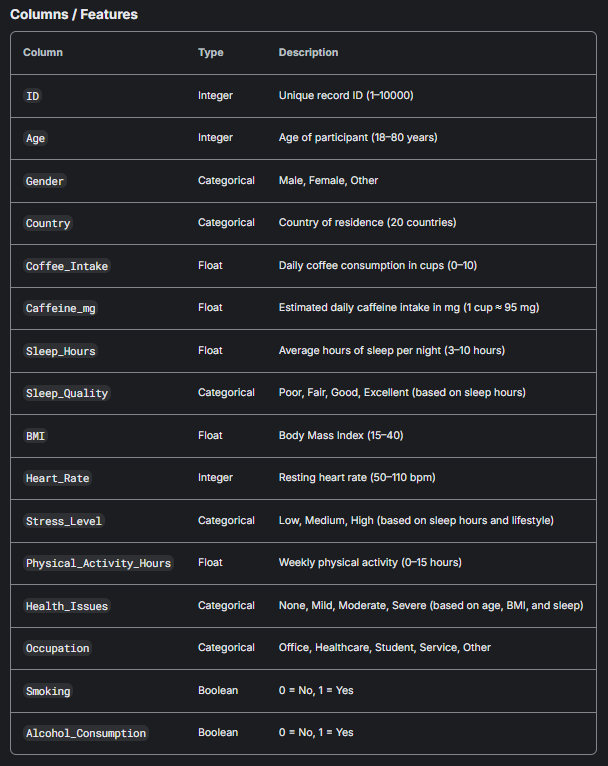

**Usage & Insights:**
- Explore correlations between coffee intake, sleep quality, and health outcomes.
- Analyze lifestyle factors like physical activity, smoking, and alcohol consumption.
- Build predictive models for sleep quality, stress levels, or health risks.
- Compare demographic and country-level patterns in caffeine consumption.
- Use as a benchmark dataset for wellness, lifestyle, or health informatics research.

### **Innitial Assumption:**
- Does mode coffee cause less hours of sleep?

### **Linear Regression Analysis for Causal Effect:**

> $y_i$ = $\beta_0$ + $\beta_1$ $D_i$ + $\epsilon_i$

$y_i$ = The outcome variable. The dependent variable.

$\beta_0$ = The average change in outcome of the control group.

$\beta_1$ = The Average Treatment Effect (ATE), or the estimated causal effect. The average difference of the change in the outcome between the treatment and control groups.

$D_i$ = The treatment variable, The independent variable. When $D_i$ = 1 = treated, when $D_i$ = 0 = control.

$\epsilon_i$ = The error term. Includes all unidentified cofounder variables.

### **Outcome Variable:**
- Sleep_Hours, Average hours of sleep per night (3–10 hours).

### **Treatment Variable:**
- Coffee_Intake, Daily coffee consumption in cups (0–10).
- This treatment variable is not binary. Instead, it is continuous (0 to 10 cups).
- Since it is continuous, there is no control and only a treatment group.
- Therefore, the average treatment effect ATE measures the average change in the outcome due to one unit increase in the treatment variable.
- Determines how much on average sleep increases/decreases by due to drinking one additional cup of coffee.

**Note:**
- It is important to note that the samples are random, however the treatment is not.
- It is a personal choice to drink coffee, and how many cups are consumed. This was not randomly assigned to individuals by the producers of the data.
- Therefore, cofounders exist and must be controlled for.

### **Possible Cofounders:**
- Age, Age of participant (18–80 years).
- Gender, Male, Female, Other.
- Country, Country of residence (20 countries).
- Caffeine_mg, Estimated daily caffeine intake in mg (1 cup ≈ 95 mg).
- Sleep_Quality, Poor, Fair, Good, Excellent (based on sleep hours).
- BMI, Body Mass Index (15–40).
- Heart_Rate, Resting heart rate (50–110 bpm).
- Stress_Level, Low, Medium, High (based on sleep hours and lifestyle).
- Physical_Activity_Hours, Weekly physical activity (0–15 hours).
- Health_Issues, None, Mild, Moderate, Severe (based on age, BMI, and sleep).
- Occupation, Office, Healthcare, Student, Service, Other.
- Smoking, 0 = No, 1 = Yes.
- Alcohol_Consumption, 0 = No, 1 = Yes.

### **Linear Regression Equation for Problem:**
> Sleep_Hours = $\beta_0$ + $\beta_1$ (Coffee_Intake) + $\beta_2$ (Age) + $\beta_3$ (Male Gender) + $\beta_4$ (Other Gender) + $\beta_5$ (Belgium) + $\beta_6$ (Brazil) + $\beta_7$ (Canada) + $\beta_8$ (China) + $\beta_9$ (Finland) + $\beta_{10}$ (France) + $\beta_{11}$ (Germany) + $\beta_{12}$ (India) + $\beta_{13}$ (Italy) + $\beta_{14}$ (Mexico) + $\beta_{15}$ (Netherlands) + $\beta_{16}$ (Norway) + $\beta_{17}$ (South Korea) + $\beta_{18}$ (Spain) + $\beta_{19}$ (Sweden) + $\beta_{20}$ (Switzerland) + $\beta_{21}$ (UK) + $\beta_{22}$ (USA) + $\beta_{23}$ (Fair Sleep Quality) + $\beta_{24}$ (Good Sleep Quality) + $\beta_{25}$ (Poor Sleep Quality) + $\beta_{26}$ (Low Stress Level) + $\beta_{27}$ (Medium Stress Level) + $\beta_{28}$ (Office Occupation) + $\beta_{29}$ (Other Occupation) + $\beta_{30}$ (Service Occupation) + $\beta_{31}$ (Student Occupation) + $\beta_{32}$ (Moderate Health Issues) + $\beta_{33}$ (None Health Issues) + $\beta_{34}$ (Severe Health Issues) + $\beta_{35}$ (Caffeine_mg) + $\beta_{36}$ (Japan) + $\beta_{37}$ (BMI) + $\beta_{38}$ (Heart_Rate) + $\beta_{39}$ (Physical_Activity_Hours) + $\beta_{40}$ (Smoking) + $\beta_{41}$ + (Alcohol_Consumption) + $\epsilon_i$

---

## **Loading, Editing, and Modifying Data:**

In [713]:
df = pd.read_csv("C:\BROCK U COURSE DOCS\DataSets\synthetic_coffee_health_10000.csv")
df

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0


In [714]:
df.duplicated().sum()

np.int64(0)

> No duplicated Rows

In [715]:
df.isna().sum()

df['Health_Issues'] = df['Health_Issues'].fillna('None')

df.isna().sum()

ID                         0
Age                        0
Gender                     0
Country                    0
Coffee_Intake              0
Caffeine_mg                0
Sleep_Hours                0
Sleep_Quality              0
BMI                        0
Heart_Rate                 0
Stress_Level               0
Physical_Activity_Hours    0
Health_Issues              0
Occupation                 0
Smoking                    0
Alcohol_Consumption        0
dtype: int64

> We assume the NaN health issues are labeled as None.

In [716]:
df = df.drop(labels= 'ID', axis= 1)

> Dropped the ID column since it is the same as the index. It is redundant.

In [717]:
genders = pd.get_dummies(data= df['Gender'], drop_first= True).astype(int)
df = pd.merge(df, genders, left_index= True, right_index= True)
df = df.drop(labels= 'Gender', axis= 1)

> Made dummy variables for male and other gender types. If both male and other are 0, the individual is female.

In [718]:
country = pd.get_dummies(data= df['Country'], drop_first= True).astype(int)
df = pd.merge(df, country, left_index= True, right_index= True)
df = df.drop(labels= 'Country', axis= 1)

> Created dummy variables for 19 countries. if all 19 are 0, then individual comes from Australia.

In [719]:
sleepQuality = pd.get_dummies(data= df['Sleep_Quality'], drop_first= True).astype(int)
df = pd.merge(df, sleepQuality, left_index= True, right_index= True)
df = df.drop(labels= 'Sleep_Quality', axis= 1)

> Created dummy varaibles for fair, good, and poor sleep quality. If all are zero, then sleep quality is excellent.

In [720]:
stress = pd.get_dummies(data= df['Stress_Level'], drop_first= True).astype(int)
df = pd.merge(df, stress, left_index= True, right_index= True)
df = df.drop(labels= 'Stress_Level', axis= 1)

> Created dummy variables for low and medium stress levels. If both are 0, then stress level is high.

In [721]:
occupation = pd.get_dummies(data= df['Occupation'], drop_first= True).astype(int)
df = pd.merge(df, occupation, left_index= True, right_index= True)
df = df.drop(labels= 'Occupation', axis= 1)

> Created dummy variables for office, other, service, and student. If all are 0, then occupation is healthcare.

In [722]:
health = pd.get_dummies(data= df['Health_Issues'], drop_first= True).astype(int)
df = pd.merge(df, health, left_index= True, right_index= True)
df = df.drop(labels= 'Health_Issues', axis= 1)

> Created dummy variables for moderate, none, and severe health issues. If all are 0, then health issues are mild.

---

## **Creating Causal Inferrence Model:**

In [723]:
df.columns

Index(['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI',
       'Heart_Rate', 'Physical_Activity_Hours', 'Smoking',
       'Alcohol_Consumption', 'Male', 'Other_x', 'Belgium', 'Brazil', 'Canada',
       'China', 'Finland', 'France', 'Germany', 'India', 'Italy', 'Japan',
       'Mexico', 'Netherlands', 'Norway', 'South Korea', 'Spain', 'Sweden',
       'Switzerland', 'UK', 'USA', 'Fair', 'Good', 'Poor', 'Low', 'Medium',
       'Office', 'Other_y', 'Service', 'Student', 'Moderate', 'None',
       'Severe'],
      dtype='object')

In [724]:
y = df['Sleep_Hours']

x = df[['Coffee_Intake', 'Age', 'Caffeine_mg', 'BMI', 'Heart_Rate', 
        'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption', 'Male', 'Other_x', 
        'Belgium', 'Brazil', 'Canada', 'China', 'Finland', 
        'France', 'Germany', 'India', 'Italy', 'Japan', 
        'Mexico', 'Netherlands', 'Norway', 'South Korea', 'Spain', 
        'Sweden', 'Switzerland', 'UK', 'USA', 'Fair', 
        'Good', 'Poor', 'Low', 'Medium', 'Office', 
        'Other_y', 'Service', 'Student', 'Moderate', 'None', 
        'Severe']]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Sleep_Hours   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     1350.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:38:16   Log-Likelihood:                -7003.8
No. Observations:               10000   AIC:                         1.409e+04
Df Residuals:                    9960   BIC:                         1.438e+04
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       4.6265      0.044    105.782      0.000       4.541       4.712
Coffee_Intake              -0.0227      0.175     -0.130      0.897      -0.365       0.320
Age                        -0.0002      0.001     -0.354      0.723      -0.001       0.001
Caffeine_mg             -2.802e-05      0.002     -0.015      0.988      -0.004       0.004
BMI                        -0.0008      0.001     -0.577      0.564      -0.003       0.002
Heart_Rate              -3.128e-05      0.000     -0.063      0.950      -0.001       0.001
Physical_Activity_Hours    -0.0005      0.001     -0.460      0.646      -0.003       0.002
Smoking                     0.0048      0.012      0.394      0.694      -0.019       0.029
Alcohol_Consumption         0.0053      0.011      0.495      0.621      -0.016       0.026
Male                        0.0031      0.010      0.312      0.755      -0.016       0.022
Other_x                    -0.0319      0.033     -0.960      0.337      -0.097       0.033
Belgium                    -0.0095      0.031     -0.305      0.760      -0.070       0.051
Brazil                     -0.0121      0.032     -0.383      0.702      -0.074       0.050
Canada                     -0.0678      0.030     -2.235      0.025      -0.127      -0.008
China                      -0.0271      0.031     -0.885      0.376      -0.087       0.033
Finland                    -0.0442      0.031     -1.433      0.152      -0.105       0.016
France                      0.0080      0.031      0.258      0.796      -0.053       0.069
Germany                    -0.0576      0.031     -1.856      0.064      -0.118       0.003
India                      -0.0268      0.031     -0.877      0.381      -0.087       0.033
Italy                      -0.0246      0.031     -0.798      0.425      -0.085       0.036
Japan                      -0.0527      0.031     -1.673      0.094      -0.114       0.009
Mexico                     -0.0244      0.031     -0.782      0.434      -0.086       0.037
Netherlands                -0.0216      0.031     -0.697      0.486      -0.083       0.039
Norway                     -0.0356      0.031     -1.163      0.245      -0.096       0.024
South Korea                -0.0179      0.031     -0.583      0.560      -0.078       0.042
Spain                      -0.0006      0.031     -0.018      0.986      -0.062       0.061
Sweden                     -0.0802      0.031     -2.607      0.009      -0.141      -0.020
Switzerland                -0.1020      0.031     -3.293      0.001      -0.163      -0.041
UK                         -0.0435      0.031     -1.417      0.157      -0.104       0.017
USA                        -0.0623      0.032     -1.956      0.050      -0.125       0.000
Fair                        0.5493      0.010  

## **Conclusion:**

### **Linear Regression Equation for Problem:**
> Sleep_Hours = 4.6265 -0.0227 (Coffee_Intake) -0.0002 (Age) + 0.0031 (Male Gender) -0.0319 (Other Gender) -0.0095 (Belgium) -0.0121 (Brazil) -0.0678 (Canada) -0.0271 (China) -0.0442 (Finland) + 0.0080 (France) -0.0576 (Germany) -0.0268 (India) -0.0246 (Italy) -0.0527 (Japan) -0.0244 (Mexico) -0.0216 (Netherlands) -0.0356 (Norway) -0.0179 (South Korea) -0.0006 (Spain) -0.0802 (Sweden) -0.1020 (Switzerland) -0.0435 (UK) -0.0623 (USA) + 0.5493 (Fair Sleep Quality) -1.6593 (Good Sleep Quality) -0.0214 (Poor Sleep Quality) + 4.0986 (Low Stress Level) + 0.5493 (Medium Stress Level) -0.0268 (Office Occupation) -0.0303 (Other Occupation) -0.0151 (Service Occupation) -0.0112 (Student Occupation) + 0.0127 (Moderate Health Issues) + 0.0003 (None Health Issues) + 0.0217 (Severe Health Issues) -2.802e-05 (Caffeine_mg) -0.0008 (BMI) -3.128e-05 (Heart_Rate) -0.0005 (Physical_Activity_Hours) + 0.0048 (Smoking) + 0.0053 + (Alcohol_Consumption) + $\epsilon_i$

### **Hypothesis Test for Treatment Beta Coefficient Significance:**

Ho: The population Coffee_Intake $\beta_1$ = 0

Ha: The population Coffee_Intake $\beta_1$ != 0

t-stat = ($\beta_1$ - 0) / SE($\beta_1$)

t-stat = (-0.0227 - 0) / 0.175

t-stat = -0.130

p-value = The probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true.

p-value = 0.897

$\alpha$ = 0.05

=> p-value > $\alpha$

=> 0.897 > 0.05

=> We fail to reject the null hypothesis; the population Coffee_Intake $\beta_1$ = 0.

### **Confidence Interval for Treatment Beta Coefficient:**

Confidence Interval = [$\beta_1$ - (t[0.05] * SE), $\beta_1$ + (t[0.05] * SE)]

Confidence Interval = [-0.0227 - (1.96 * 0.175), -0.0227 + (1.96 * 0.175)]

Confidence Interval = [-0.365, 0.320]

=> Confidence interval contains Zero.

=> Therefore results confirm hypothesis test and population Coffee_Intake $\beta_1$ is zero.

### **Description, Reasoning, and Summary:**
- The model does confirm the relationship presented in the innitial assumption, which states that coffee consumption causes less hours of sleep?
- The average treatment effect ATE, or the average change in the outcome (hourse of sleep) due to one unit increase in the treatment (one cup of coffee consumed) is -0.0227.
- For each additional cup of coffee consumed each day, this will lead to an average decrease of 0.0227 of hours of sleep per night.
- However, this relationship not causal. The reasons for this is that the ATE is not significant, and the treatment is not random and it is not possible to control for all existant cofounders.
- The best we can do is infer causality, but we cannot since the change in hours of sleep due to one additional cup of coffee consumed is not significant.
- The test statistic is extremely low, and the probability of observing a test statistic as extreme as the one observed, given the null hypothesis is true, is very high.
- Therefore, the difference in the ATE and zero is very low, making the ATE practically zero, which confirms the truth of the null hypothesis.
- So, the probability under the assumption the null hypothesis is true is high since the sample data confirms it.
- The population ATE is likely to be zero, and so the relationship is not statistically significant. We cannot infer causality.

---